In [4]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the dataset
file_path = 'creditcard.csv'  # File source
df = pd.read_csv(file_path)

# Separating features and the target variable
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Splitting the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1000, stratify=y)

# Standardizing the feature columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handling class imbalance using SMOTE (Synthetic Minority Oversampling Technique)
smote = SMOTE(random_state=1000)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Training the XGBoost model
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train_resampled, y_train_resampled)

# Making predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)



Accuracy: 0.999385555282469
Precision: 0.8118811881188119
Recall: 0.8367346938775511
F1 Score: 0.8241206030150754
Confusion Matrix:
[[56845    19]
 [   16    82]]


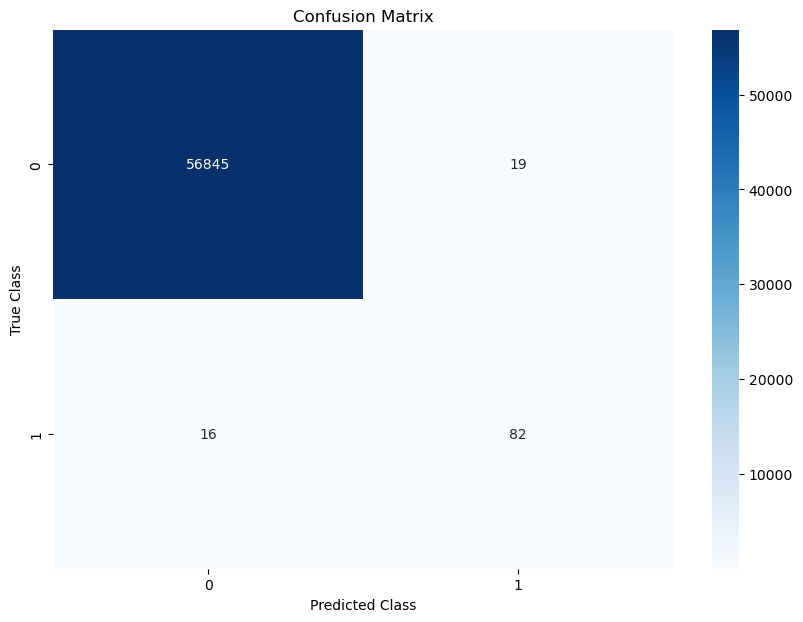

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns


# Visualizing the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()




# Recommendations and Conclusion:
# XGBoost is powerful for handling complex datasets and can manage class imbalance effectively.
# SMOTE has been used to address the class imbalance in the dataset by oversampling the minority, which is critical for fraud detection.
# We got high accuracy at 0.999 but moderate F1 score at 0.82. To balance false positive and false negative more, we can do
# Hyperparametar tuning and cross-valudation to improve the model performance and prevent overfitting.
# Increasing the random state seem to increase the F1 score

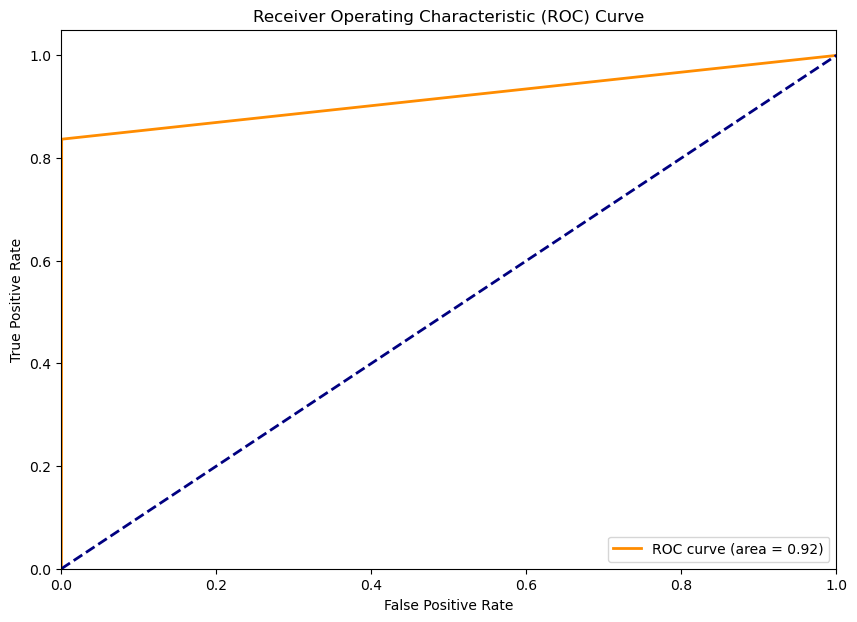

In [6]:
# ROC Curve and AUC (Area Under the Curve):

from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



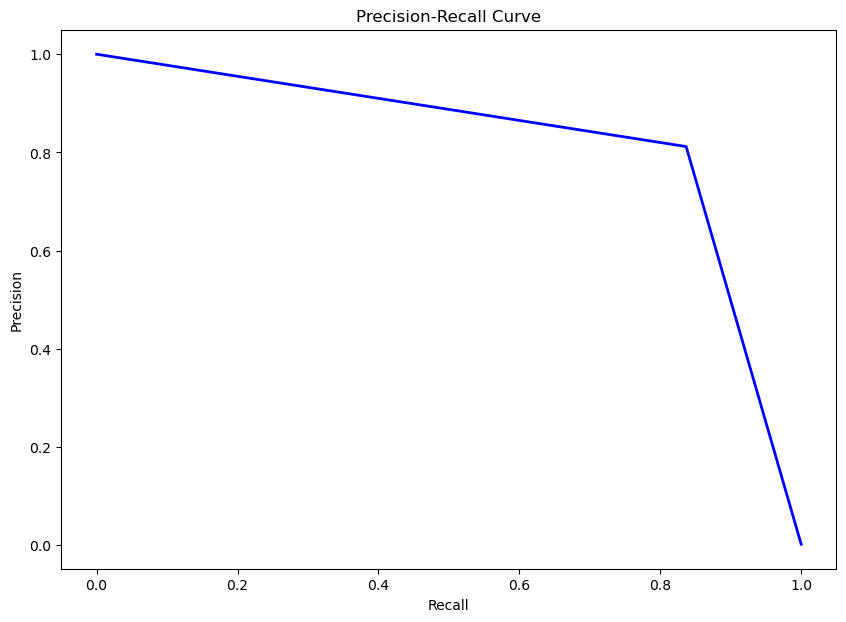

In [7]:
# Precision-Recall Curve:

from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Plotting the Precision-Recall Curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()



C:\Users\rijan\AppData\Local\Temp\ipykernel_39064\3512808108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=X.columns, palette='coolwarm')


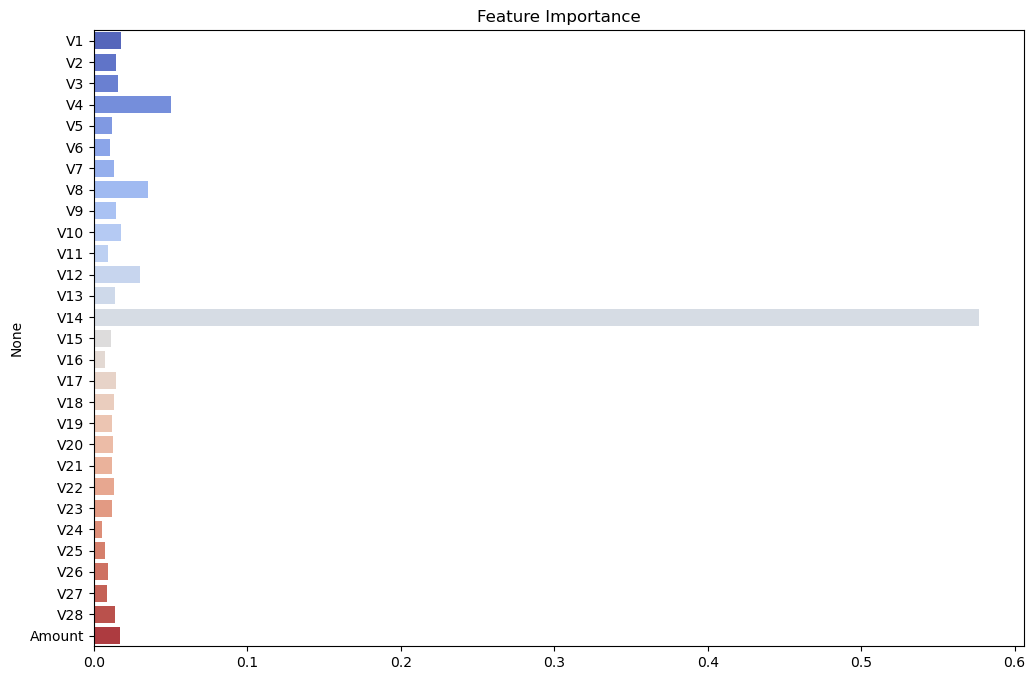

In [8]:
# Feature Importance Plot:

plt.figure(figsize=(12, 8))
importance = model.feature_importances_
sns.barplot(x=importance, y=X.columns, palette='coolwarm')
plt.title('Feature Importance')
plt.show()


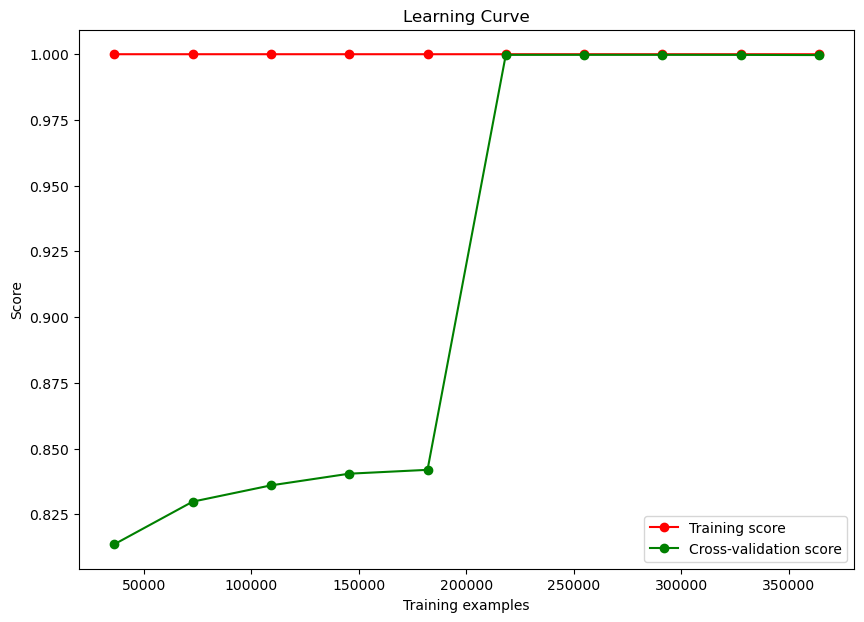

In [11]:
# Learning Curve:

import numpy as np  
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Assuming `model`, `X_train_resampled`, and `y_train_resampled` are already defined

# Learning Curve:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
plt.title('Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc='best')
plt.show()



<Figure size 1000x700 with 0 Axes>

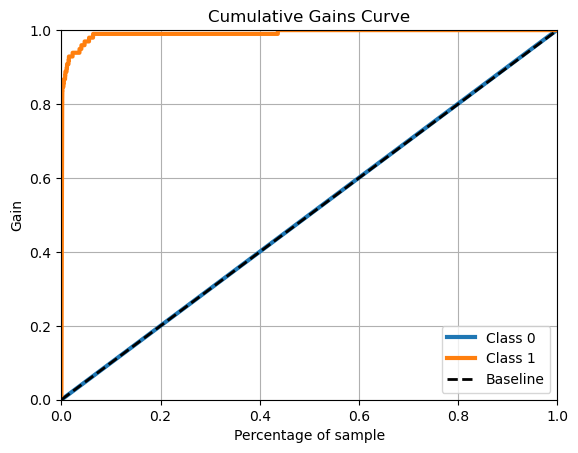

<Figure size 1000x700 with 0 Axes>

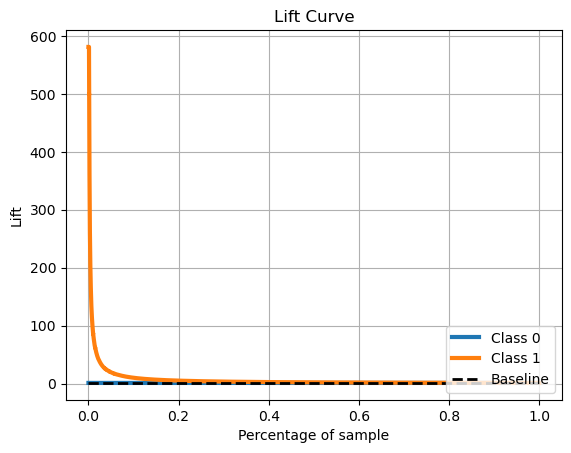

In [15]:
#  Cumulative Gains and Lift Charts:

import scikitplot as skplt
import matplotlib.pyplot as plt

# Assuming `model`, `X_test_scaled`, and `y_test` are already defined

# Cumulative Gains Plot
plt.figure(figsize=(10, 7))
skplt.metrics.plot_cumulative_gain(y_test, model.predict_proba(X_test_scaled))
plt.show()

# Lift Curve
plt.figure(figsize=(10, 7))
skplt.metrics.plot_lift_curve(y_test, model.predict_proba(X_test_scaled))
plt.show()


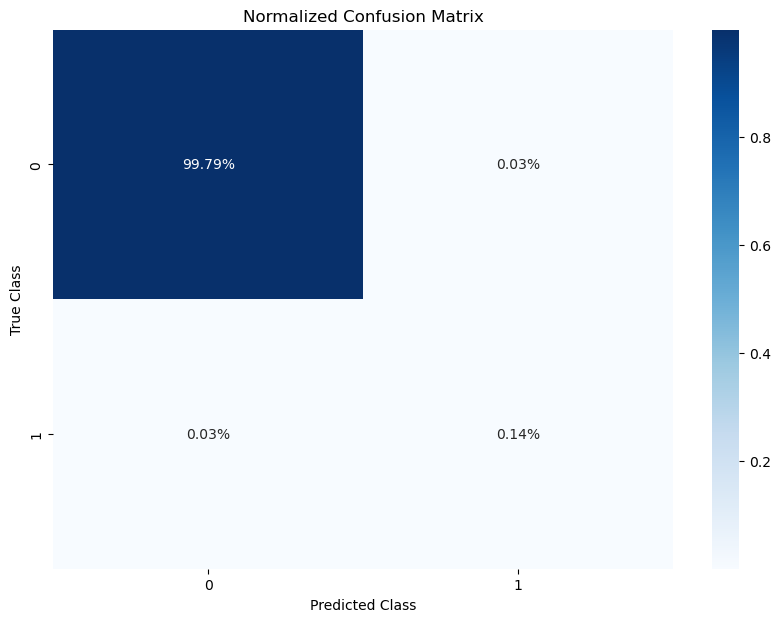

In [16]:
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix/np.sum(conf_matrix), annot=True, fmt='.2%', cmap='Blues')
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()
